In [3]:
!pip install -q stable-baselines3[extra] gymnasium[box2d] imageio matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 98.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 102.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 103.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 20.9 MB/s eta 0:00:00


In [4]:
import os
import gymnasium as gym
import numpy as np
import imageio
import matplotlib.pyplot as plt

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.evaluation import evaluate_policy

from IPython.display import Image, display

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
LOG_DIR = "./logs"
MODEL_DIR = "./models"
GIF_DIR = "./gifs"

os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(GIF_DIR, exist_ok=True)

TOTAL_TIMESTEPS = 400_000
ENV_ID = "LunarLanderContinuous-v3"

In [6]:
# -------- Reward Wrapper --------
class LunarRewardWrapper(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)

        action = np.array(action)

        main_penalty = 0.03 * abs(action[0])
        side_penalty = 0.015 * abs(action[1])

        vx, vy = obs[2], obs[3]
        speed_penalty = 0.03 * (abs(vx) + abs(vy))

        x, y = obs[0], obs[1]
        smooth_bonus = 0
        if abs(x) < 0.2 and y < 0.25:
            smooth_bonus += 3.0 * max(0, 1 - abs(vy))
            smooth_bonus += 2.0 * max(0, 1 - abs(vx))

        if terminated and reward < -50:
            reward -= 100

        reward = reward - main_penalty - side_penalty - speed_penalty + smooth_bonus

        return obs, reward, terminated, truncated, info


# -------- Environments --------
def make_baseline_env(log_dir=None):
    env = gym.make(ENV_ID)
    return Monitor(env, log_dir) if log_dir else Monitor(env)


def make_improved_env(rank, log_dir=None):
    def _init():
        env = gym.make(ENV_ID)
        env = LunarRewardWrapper(env)
        return Monitor(env, os.path.join(log_dir, f"env_{rank}")) if log_dir else Monitor(env)
    return _init


# -------- Evaluation --------
def evaluate_model(model, env_fn, n_episodes=10):
    env = env_fn()
    mean, std = evaluate_policy(model, env, n_eval_episodes=n_episodes, deterministic=True)
    env.close()
    return mean, std


# -------- GIF --------
def record_gif(model, filename, reward_wrapper=False):
    env = gym.make(ENV_ID, render_mode="rgb_array")

    if reward_wrapper:
        env = LunarRewardWrapper(env)

    obs, _ = env.reset()
    frames = []

    for _ in range(1000):
        frames.append(env.render())
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = env.step(action)

        if terminated or truncated:
            break

    env.close()

    path = os.path.join(GIF_DIR, filename)
    imageio.mimsave(path, frames, fps=30)
    return path


def record_progress(model, name):
    path = record_gif(model, f"{name}.gif", reward_wrapper=True)
    print(f"Saved: {path}")

In [7]:
baseline_log_dir = os.path.join(LOG_DIR, "baseline")
os.makedirs(baseline_log_dir, exist_ok=True)

baseline_env = make_baseline_env(baseline_log_dir)

baseline_model = PPO("MlpPolicy", baseline_env, verbose=1)

baseline_model.learn(total_timesteps=TOTAL_TIMESTEPS)

baseline_model.save(os.path.join(MODEL_DIR, "ppo_lunar_baseline"))
baseline_env.close()

<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute


Using cuda device
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 198      |
|    ep_rew_mean     | -232     |
| time/              |          |
|    fps             | 656      |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 148         |
|    ep_rew_mean          | -207        |
| time/                   |             |
|    fps                  | 499         |
|    iterations           | 2           |
|    time_elapsed         | 8           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.004729879 |
|    clip_fraction        | 0.0284      |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.85       |
|    explained_variance   | 0.00294     |
|    learning_rate        | 0.

In [8]:
N_ENVS = 4

improved_log_dir = os.path.join(LOG_DIR, "improved")
os.makedirs(improved_log_dir, exist_ok=True)

improved_env = SubprocVecEnv([
    make_improved_env(i, improved_log_dir) for i in range(N_ENVS)
])

improved_model = PPO(
    "MlpPolicy",
    improved_env,
    learning_rate=2.5e-4,
    n_steps=2048,
    batch_size=64,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.001,
    vf_coef=0.5,
    max_grad_norm=0.5,
    verbose=1
)

# Training in stages
improved_model.learn(total_timesteps=100_000)
record_progress(improved_model, "step_100k")

improved_model.learn(total_timesteps=100_000)
record_progress(improved_model, "step_200k")

improved_model.learn(total_timesteps=200_000)
record_progress(improved_model, "step_400k")

improved_model.save(os.path.join(MODEL_DIR, "ppo_lunar_improved"))
improved_env.close()

Using cuda device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 127      |
|    ep_rew_mean     | -318     |
| time/              |          |
|    fps             | 1487     |
|    iterations      | 1        |
|    time_elapsed    | 5        |
|    total_timesteps | 8192     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 129          |
|    ep_rew_mean          | -255         |
| time/                   |              |
|    fps                  | 991          |
|    iterations           | 2            |
|    time_elapsed         | 16           |
|    total_timesteps      | 16384        |
| train/                  |              |
|    approx_kl            | 0.0037878058 |
|    clip_fraction        | 0.0195       |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.84        |
|    explained_variance   | -0.00431    

/usr/local/lib/python3.12/dist-packages/imageio/plugins/pillow.py:410: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(


Saved: ./gifs/step_100k.gif
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 345      |
|    ep_rew_mean     | 67.2     |
| time/              |          |
|    fps             | 1662     |
|    iterations      | 1        |
|    time_elapsed    | 4        |
|    total_timesteps | 8192     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 422          |
|    ep_rew_mean          | 349          |
| time/                   |              |
|    fps                  | 1009         |
|    iterations           | 2            |
|    time_elapsed         | 16           |
|    total_timesteps      | 16384        |
| train/                  |              |
|    approx_kl            | 0.0041297805 |
|    clip_fraction        | 0.0268       |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.78        |
|    explained_variance   | 0.

In [9]:
baseline_model = PPO.load(os.path.join(MODEL_DIR, "ppo_lunar_baseline"))
improved_model = PPO.load(os.path.join(MODEL_DIR, "ppo_lunar_improved"))

baseline_mean, _ = evaluate_model(
    baseline_model, lambda: make_baseline_env()
)

improved_mean, _ = evaluate_model(
    improved_model,
    lambda: Monitor(LunarRewardWrapper(gym.make(ENV_ID)))
)

print("Baseline Reward:", baseline_mean)
print("Improved Reward:", improved_mean)

Baseline Reward: 63.60061830000001
Improved Reward: 832.8233200000001


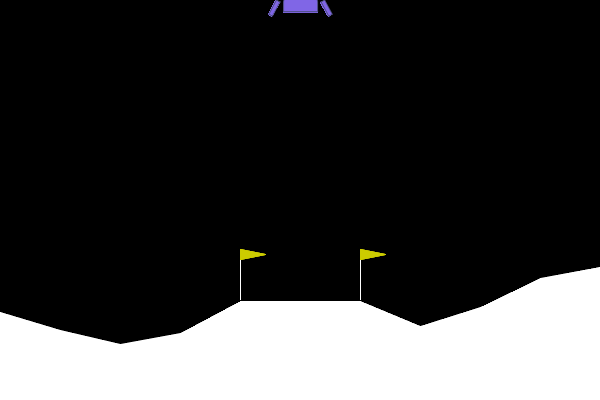

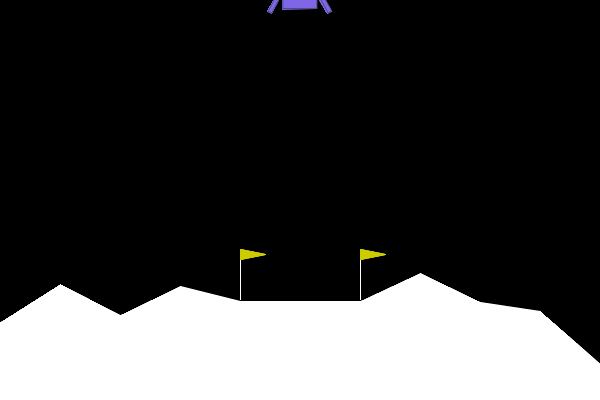

In [10]:
baseline_gif = record_gif(baseline_model, "baseline.gif", False)
improved_gif = record_gif(improved_model, "improved.gif", True)

display(Image(filename=baseline_gif))
display(Image(filename=improved_gif))

In [11]:
import os
print(os.listdir("./gifs"))

['step_100k.gif', 'step_200k.gif', 'improved.gif', 'step_400k.gif', 'baseline.gif']


In [12]:
from google.colab import files

files.download("./gifs/baseline.gif")
files.download("./gifs/improved.gif")
files.download("./gifs/step_100k.gif")
files.download("./gifs/step_200k.gif")
files.download("./gifs/step_400k.gif")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>